First 5 Rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

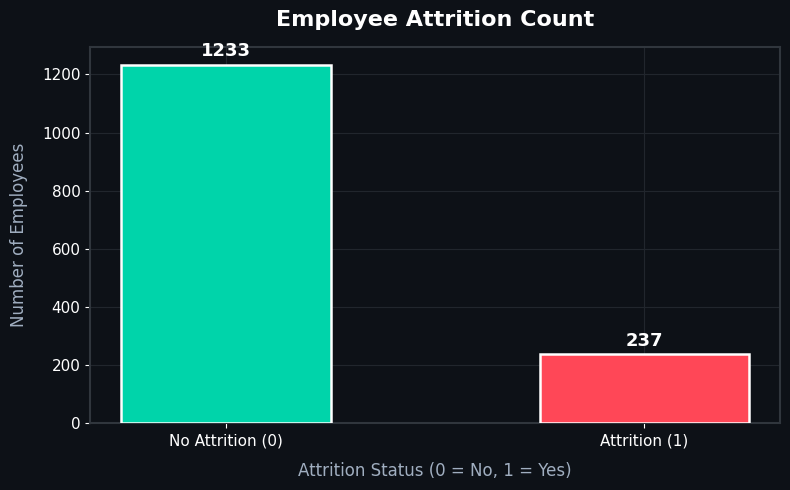

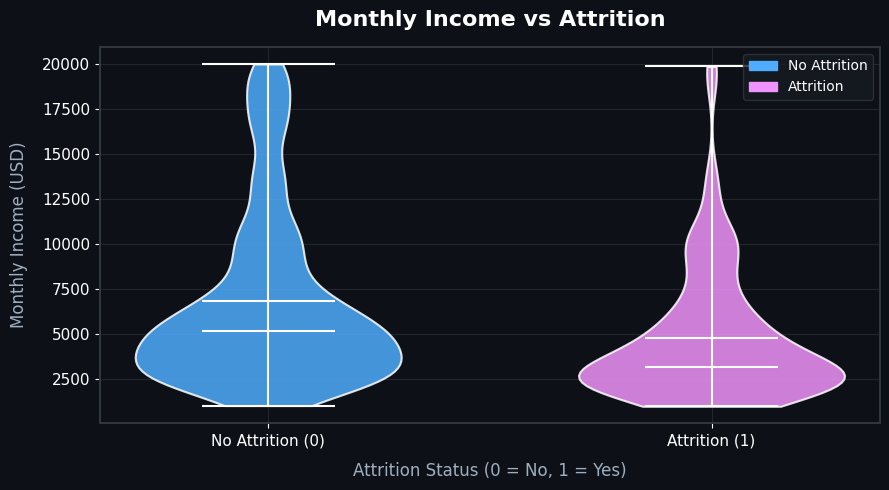

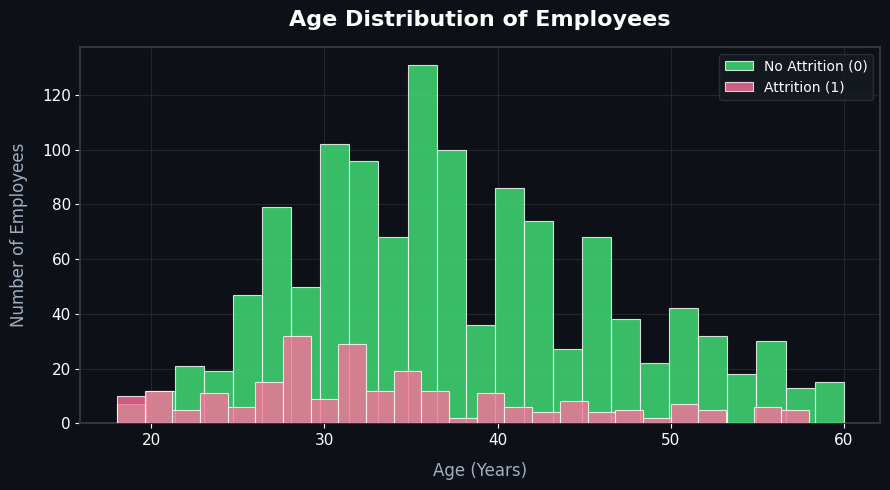


Top Important Features:
               Feature  Importance
15       MonthlyIncome    0.078212
18            OverTime    0.066669
0                  Age    0.061569
2            DailyRate    0.054087
23   TotalWorkingYears    0.052491
16         MonthlyRate    0.048373
9           HourlyRate    0.047369
4     DistanceFromHome    0.045999
26      YearsAtCompany    0.041347
17  NumCompaniesWorked    0.037951


C:\Users\Diganta Maity\AppData\Local\Temp\ipykernel_7508\1841977824.py:220: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('plasma', len(feature_importance))


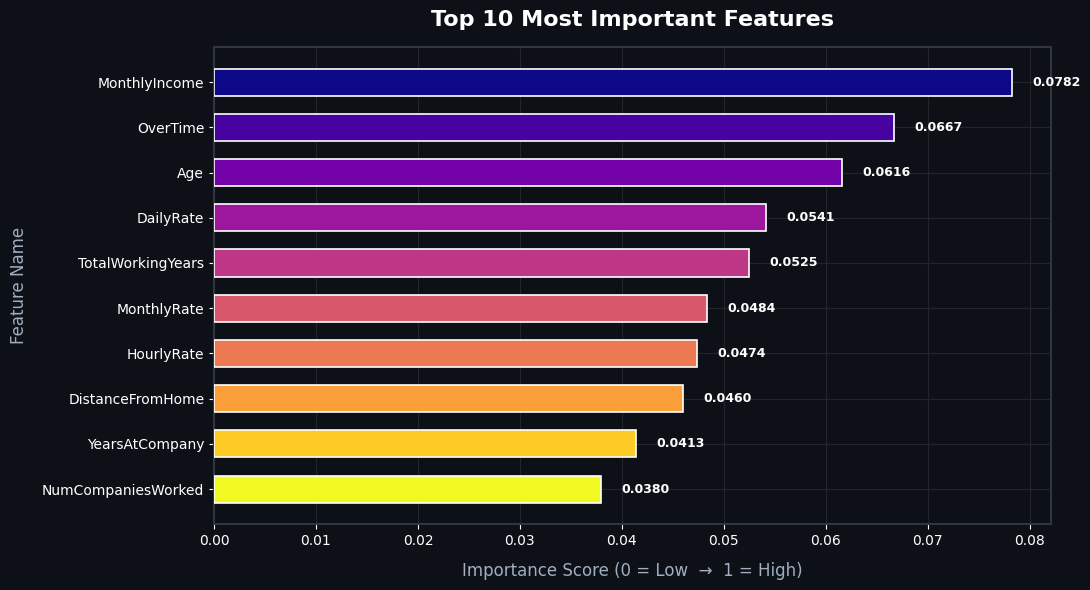

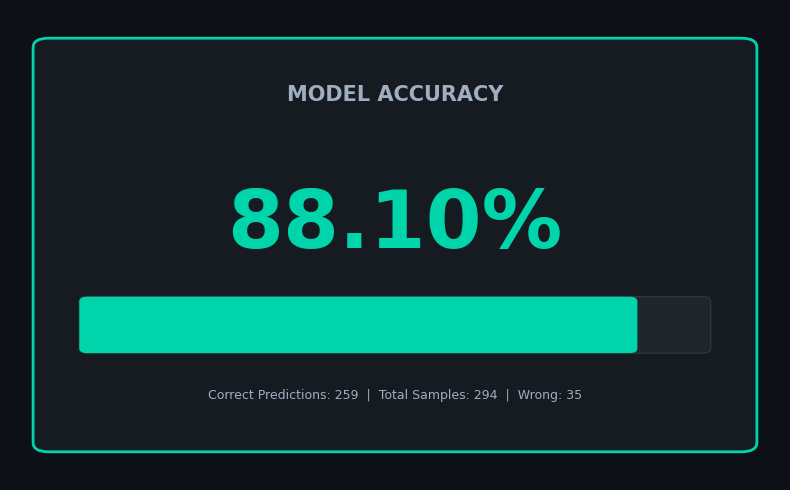

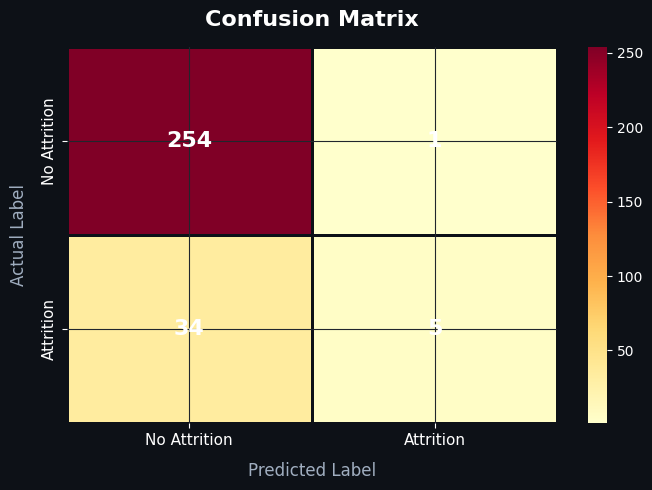


Project Completed Successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path

file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
possible_paths = [
    Path("C:/Users/Diganta Maity/Documents/Employee-Attrition-Prediction/data") / file_name,
    Path.cwd() / file_name,
    Path.cwd() / "data" / file_name,
    Path.cwd().parent / "data" / file_name,
]

data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    data_path = next(Path.cwd().rglob(file_name), None)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find {file_name}. Searched paths: "
        + ", ".join(str(p) for p in possible_paths)
    )

df = pd.read_csv(data_path)

print("First 5 Rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

le = LabelEncoder()
for column in df.columns:
    if pd.api.types.is_string_dtype(df[column]) or pd.api.types.is_object_dtype(df[column]):
        df[column] = le.fit_transform(df[column].astype(str))

remaining = df.select_dtypes(include=['object', 'string']).columns.tolist()
assert len(remaining) == 0, f"Still has string columns: {remaining}"

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report  = classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition'])
cm      = confusion_matrix(y_test, y_pred)

print("\n" + "="*50)
print("         MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"  Accuracy Score : {accuracy * 100:.2f}%")
print("="*50)
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(cm)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': '#0d1117',
    'figure.facecolor': '#0d1117',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#30363d',
    'grid.color': '#21262d',
    'grid.linewidth': 0.8,
    'axes.grid': True,
})

# - CHART 1 : Employee Attrition Count
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')

attrition_counts = df['Attrition'].value_counts().sort_index()
colors = ['#00d4aa', '#ff4757']
bars = ax.bar(
    ['No Attrition (0)', 'Attrition (1)'],
    attrition_counts.values,
    color=colors,
    edgecolor='white',
    linewidth=1.8,
    width=0.5,
    zorder=3
)

for bar, val in zip(bars, attrition_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f'{val}',
        ha='center', va='bottom',
        color='white', fontsize=13, fontweight='bold'
    )

for bar, color in zip(bars, colors):
    ax.bar(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        width=bar.get_width(),
        color=color,
        alpha=0.15,
        zorder=2
    )

ax.set_title('Employee Attrition Count', fontsize=16, fontweight='bold',
             color='white', pad=15)
ax.set_xlabel('Attrition Status (0 = No, 1 = Yes)', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_ylabel('Number of Employees', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_facecolor('#0d1117')
ax.spines[:].set_color('#30363d')
ax.spines[:].set_linewidth(1.5)
ax.tick_params(colors='white', labelsize=11)
ax.yaxis.grid(True, color='#21262d', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart1_attrition_count.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# - CHART 2 : Monthly Income vs Attrition 
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')

income_data = [
    df[df['Attrition'] == 0]['MonthlyIncome'].values,
    df[df['Attrition'] == 1]['MonthlyIncome'].values
]
vp = ax.violinplot(income_data, positions=[0, 1], widths=0.6,
                   showmeans=True, showmedians=True)

violin_colors = ['#4facfe', '#f093fb']
for i, (body, color) in enumerate(zip(vp['bodies'], violin_colors)):
    body.set_facecolor(color)
    body.set_edgecolor('white')
    body.set_alpha(0.85)
    body.set_linewidth(1.5)

for part in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    if part in vp:
        vp[part].set_color('white')
        vp[part].set_linewidth(1.5)

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Attrition (0)', 'Attrition (1)'], fontsize=11, color='white')
ax.set_title('Monthly Income vs Attrition', fontsize=16, fontweight='bold',
             color='white', pad=15)
ax.set_xlabel('Attrition Status (0 = No, 1 = Yes)', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_ylabel('Monthly Income (USD)', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_facecolor('#0d1117')
ax.spines[:].set_color('#30363d')
ax.spines[:].set_linewidth(1.5)
ax.tick_params(colors='white', labelsize=11)
ax.yaxis.grid(True, color='#21262d', linewidth=0.8)
ax.set_axisbelow(True)
patch1 = mpatches.Patch(color='#4facfe', label='No Attrition')
patch2 = mpatches.Patch(color='#f093fb', label='Attrition')
ax.legend(handles=[patch1, patch2], facecolor='#161b22', edgecolor='#30363d',
          labelcolor='white', fontsize=10)
plt.tight_layout()
plt.savefig('chart2_monthly_income.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# - CHART 3 : Age Distribution 
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')

age_no  = df[df['Attrition'] == 0]['Age']
age_yes = df[df['Attrition'] == 1]['Age']

ax.hist(age_no,  bins=25, color='#43e97b', edgecolor='white',
        linewidth=0.8, alpha=0.80, label='No Attrition (0)', zorder=3)
ax.hist(age_yes, bins=25, color='#fa709a', edgecolor='white',
        linewidth=0.8, alpha=0.80, label='Attrition (1)',    zorder=3)

ax.set_title('Age Distribution of Employees', fontsize=16, fontweight='bold',
             color='white', pad=15)
ax.set_xlabel('Age (Years)', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_ylabel('Number of Employees', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_facecolor('#0d1117')
ax.spines[:].set_color('#30363d')
ax.spines[:].set_linewidth(1.5)
ax.tick_params(colors='white', labelsize=11)
ax.yaxis.grid(True, color='#21262d', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.savefig('chart3_age_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# -CHART 4 : Top 10 Feature Importance 
importance = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False).head(10)

print("\nTop Important Features:")
print(feature_importance)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d1117')

cmap   = plt.cm.get_cmap('plasma', len(feature_importance))
colors = [cmap(i) for i in range(len(feature_importance))]

bars = ax.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=1.2,
    height=0.6,
    zorder=3
)

for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', color='white', fontsize=9, fontweight='bold'
    )

ax.set_title('Top 10 Most Important Features', fontsize=16, fontweight='bold',
             color='white', pad=15)
ax.set_xlabel('Importance Score (0 = Low  →  1 = High)', fontsize=12,
              color='#a0aec0', labelpad=10)
ax.set_ylabel('Feature Name', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_facecolor('#0d1117')
ax.spines[:].set_color('#30363d')
ax.spines[:].set_linewidth(1.5)
ax.tick_params(colors='white', labelsize=10)
ax.xaxis.grid(True, color='#21262d', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart4_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# -CHART 5 : Accuracy Visual Card 
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.add_patch(mpatches.FancyBboxPatch(
    (0.05, 0.08), 0.90, 0.84,
    boxstyle="round,pad=0.02",
    linewidth=2,
    edgecolor='#00d4aa',
    facecolor='#161b22'
))

ax.text(0.5, 0.82, 'MODEL ACCURACY', ha='center', va='center',
        fontsize=15, fontweight='bold', color='#a0aec0')

ax.text(0.5, 0.54, f'{accuracy * 100:.2f}%', ha='center', va='center',
        fontsize=58, fontweight='bold', color='#00d4aa')

bar_bg = mpatches.FancyBboxPatch(
    (0.10, 0.28), 0.80, 0.10,
    boxstyle="round,pad=0.01",
    linewidth=1, edgecolor='#30363d', facecolor='#21262d'
)
ax.add_patch(bar_bg)

bar_fill = mpatches.FancyBboxPatch(
    (0.10, 0.28), 0.80 * accuracy, 0.10,
    boxstyle="round,pad=0.01",
    linewidth=0, edgecolor='none', facecolor='#00d4aa'
)
ax.add_patch(bar_fill)

ax.text(0.5, 0.18, f'Correct Predictions: {int(accuracy * len(y_test))}  |  '
                   f'Total Samples: {len(y_test)}  |  '
                   f'Wrong: {len(y_test) - int(accuracy * len(y_test))}',
        ha='center', va='center', fontsize=9, color='#a0aec0')

plt.tight_layout()
plt.savefig('chart5_accuracy_card.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# - CHART 6 : Confusion Matrix Heatmap 
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=2,
    linecolor='#0d1117',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition'],
    annot_kws={"size": 16, "weight": "bold", "color": "white"},
    ax=ax
)

ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12, color='#a0aec0', labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, color='#a0aec0', labelpad=10)
ax.tick_params(colors='white', labelsize=11)
plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\nProject Completed Successfully")
